In [1]:
import os
import os.path as op

import importlib

import numpy as np
import pandas as pd

import nibabel as nib
from nilearn import datasets, image

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpecFromSubplotSpec

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from seaborn import kdeplot

from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import networkx as nx

import h5py

import dgsp
import bimod_plots as plot

import data_load as dload
import bundle as b_utils

In [2]:
import sys
path_to_effective = "../../effectivedelay_estimation"
sys.path.append(path_to_effective)

from src import regmod
from src import utils
from src import solver

path_to_ressources = op.join(path_to_effective, "resources")
path_to_data = "/Users/acionca/data"

In [6]:
importlib.reload(dload)
importlib.reload(dgsp)

delay_max = 100

# all_scales = [1, 2, 3, 4]
all_scales = [1,2, 3, 4]

all_n_vec = np.arange(2, 10)
all_kmeans = np.arange(20, 160, 2)

scale = 2
use_delay=False
k_threshold=0

k_matrix, labels, node_centers = dload.load_brain_graph(path_to_data=path_to_ressources,
                                                        delay_max=delay_max,
                                                        data_suffix="Laus2018_",
                                                        scale=scale,
                                                        b_prob_threshold=0.4,
                                                        slines_theshold=0,
                                                        f_prob_threshold=0,
                                                        k_threshold=k_threshold,
                                                        use_delay=use_delay,
                                                        undirected=True,
                                                        log_slines=False,
                                                        normalize_slines=False,
                                                        gamma_dir=1,
                                                        verbose=True)

graph = k_matrix.copy()

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph))
V = Vh.T

atlas_dict, b_count_img, gm_rois_array = b_utils.get_bundle_data(path_to_data=path_to_data,
                                                                    path_to_ressources=path_to_ressources,
                                                                    scale=scale)

path_to_benchmark = "/Users/acionca/code/dGSP/dSVD/results/BrainBicom-Benchmark"
os.makedirs(op.join(path_to_benchmark, f"scale{scale}"), exist_ok=True)

path_to_fig = op.join(path_to_benchmark, "figures", f"scale{scale}")
os.makedirs(path_to_fig, exist_ok=True)

n_nodes = len(S)

corr_labels = [f"$N_{{vec}}={n}$, $K_{{means}}={k}$" for n in all_n_vec for k in all_kmeans]

n_vec_max = 10
n_kmeans = 24
undir = False

all_maxiters = [300, 500, 1000]
all_maxiters = [1e-4, 1e-8, 1e-15]

cmap_name = "turbo"
cluster_cmap = LinearSegmentedColormap.from_list("colors", ["k"] + [plt.get_cmap(cmap_name, n_kmeans+2)(i+1) for i in range(n_kmeans)])

ncols = len(all_maxiters)
# fig, axes = plt.subplots(nrows=2, ncols=ncols, figsize=(6*ncols, 12))

scale_factor = S[:n_vec_max]

There are 141 nodes in the graph
69.79% of connections remain after thresholding
Is it undirected ? True


In [7]:
importlib.reload(dgsp)

n_kmeans = 40

angle_signs = np.sign([v.T @ u for u, v in zip(U[:, :n_vec_max].T, V[:, :n_vec_max].T)])

init_centers = np.random.uniform(-1, 1, (n_kmeans//2, 2*n_vec_max))
for i in range(n_vec_max):
    init_centers[:, i] *= 0.1 * S[i]
    init_centers[:, i+n_vec_max] *= 0.1 * S[i]

flipped_centers = np.concatenate([init_centers[:, n_vec_max:] * angle_signs,
                                  init_centers[:, :n_vec_max] * angle_signs], axis=1)
init_centers = np.concatenate([init_centers, flipped_centers], axis=0)

kmeans, e_assign = dgsp.edge_bicommunities(
    graph, U, V, 
    n_vec_max,
    method="kmeans",
    n_kmeans=n_kmeans,
    verbose=False,
    max_k=50,
    scale_S=scale_factor,
    # tol=1e-3,
    tol=1e-10,
    n_init=100,
    max_iter=5,
    return_kmeans=True,
    # init=init_centers,
    # assign_only=True,
    undirected=False)

initial_centers = kmeans.cluster_centers_.copy()
flipped_centers = np.concatenate([kmeans.cluster_centers_[:, n_vec_max:],
                                  kmeans.cluster_centers_[:, :n_vec_max]] * angle_signs, axis=1)

dist_mat = cdist(kmeans.cluster_centers_, flipped_centers)
row, col = linear_sum_assignment(dist_mat)
updated_centroids = (kmeans.cluster_centers_[row] + flipped_centers[col])/2

kmeans_2nd, e_assign = dgsp.edge_bicommunities(
    graph, U, V, 
    n_vec_max,
    method="kmeans",
    n_kmeans=n_kmeans,
    verbose=False,
    max_k=50,
    scale_S=scale_factor,
    tol=1e-10,
    n_init=1,
    init=updated_centroids,
    return_kmeans=True,
    # assign_only=True,
    undirected=False,)

final_centroids = kmeans_2nd.cluster_centers_.copy()

edge_clusters = kmeans_2nd.labels_ + 1
edge_clusters_mat = np.zeros(graph.shape)
edge_clusters_mat[graph != 0] = edge_clusters

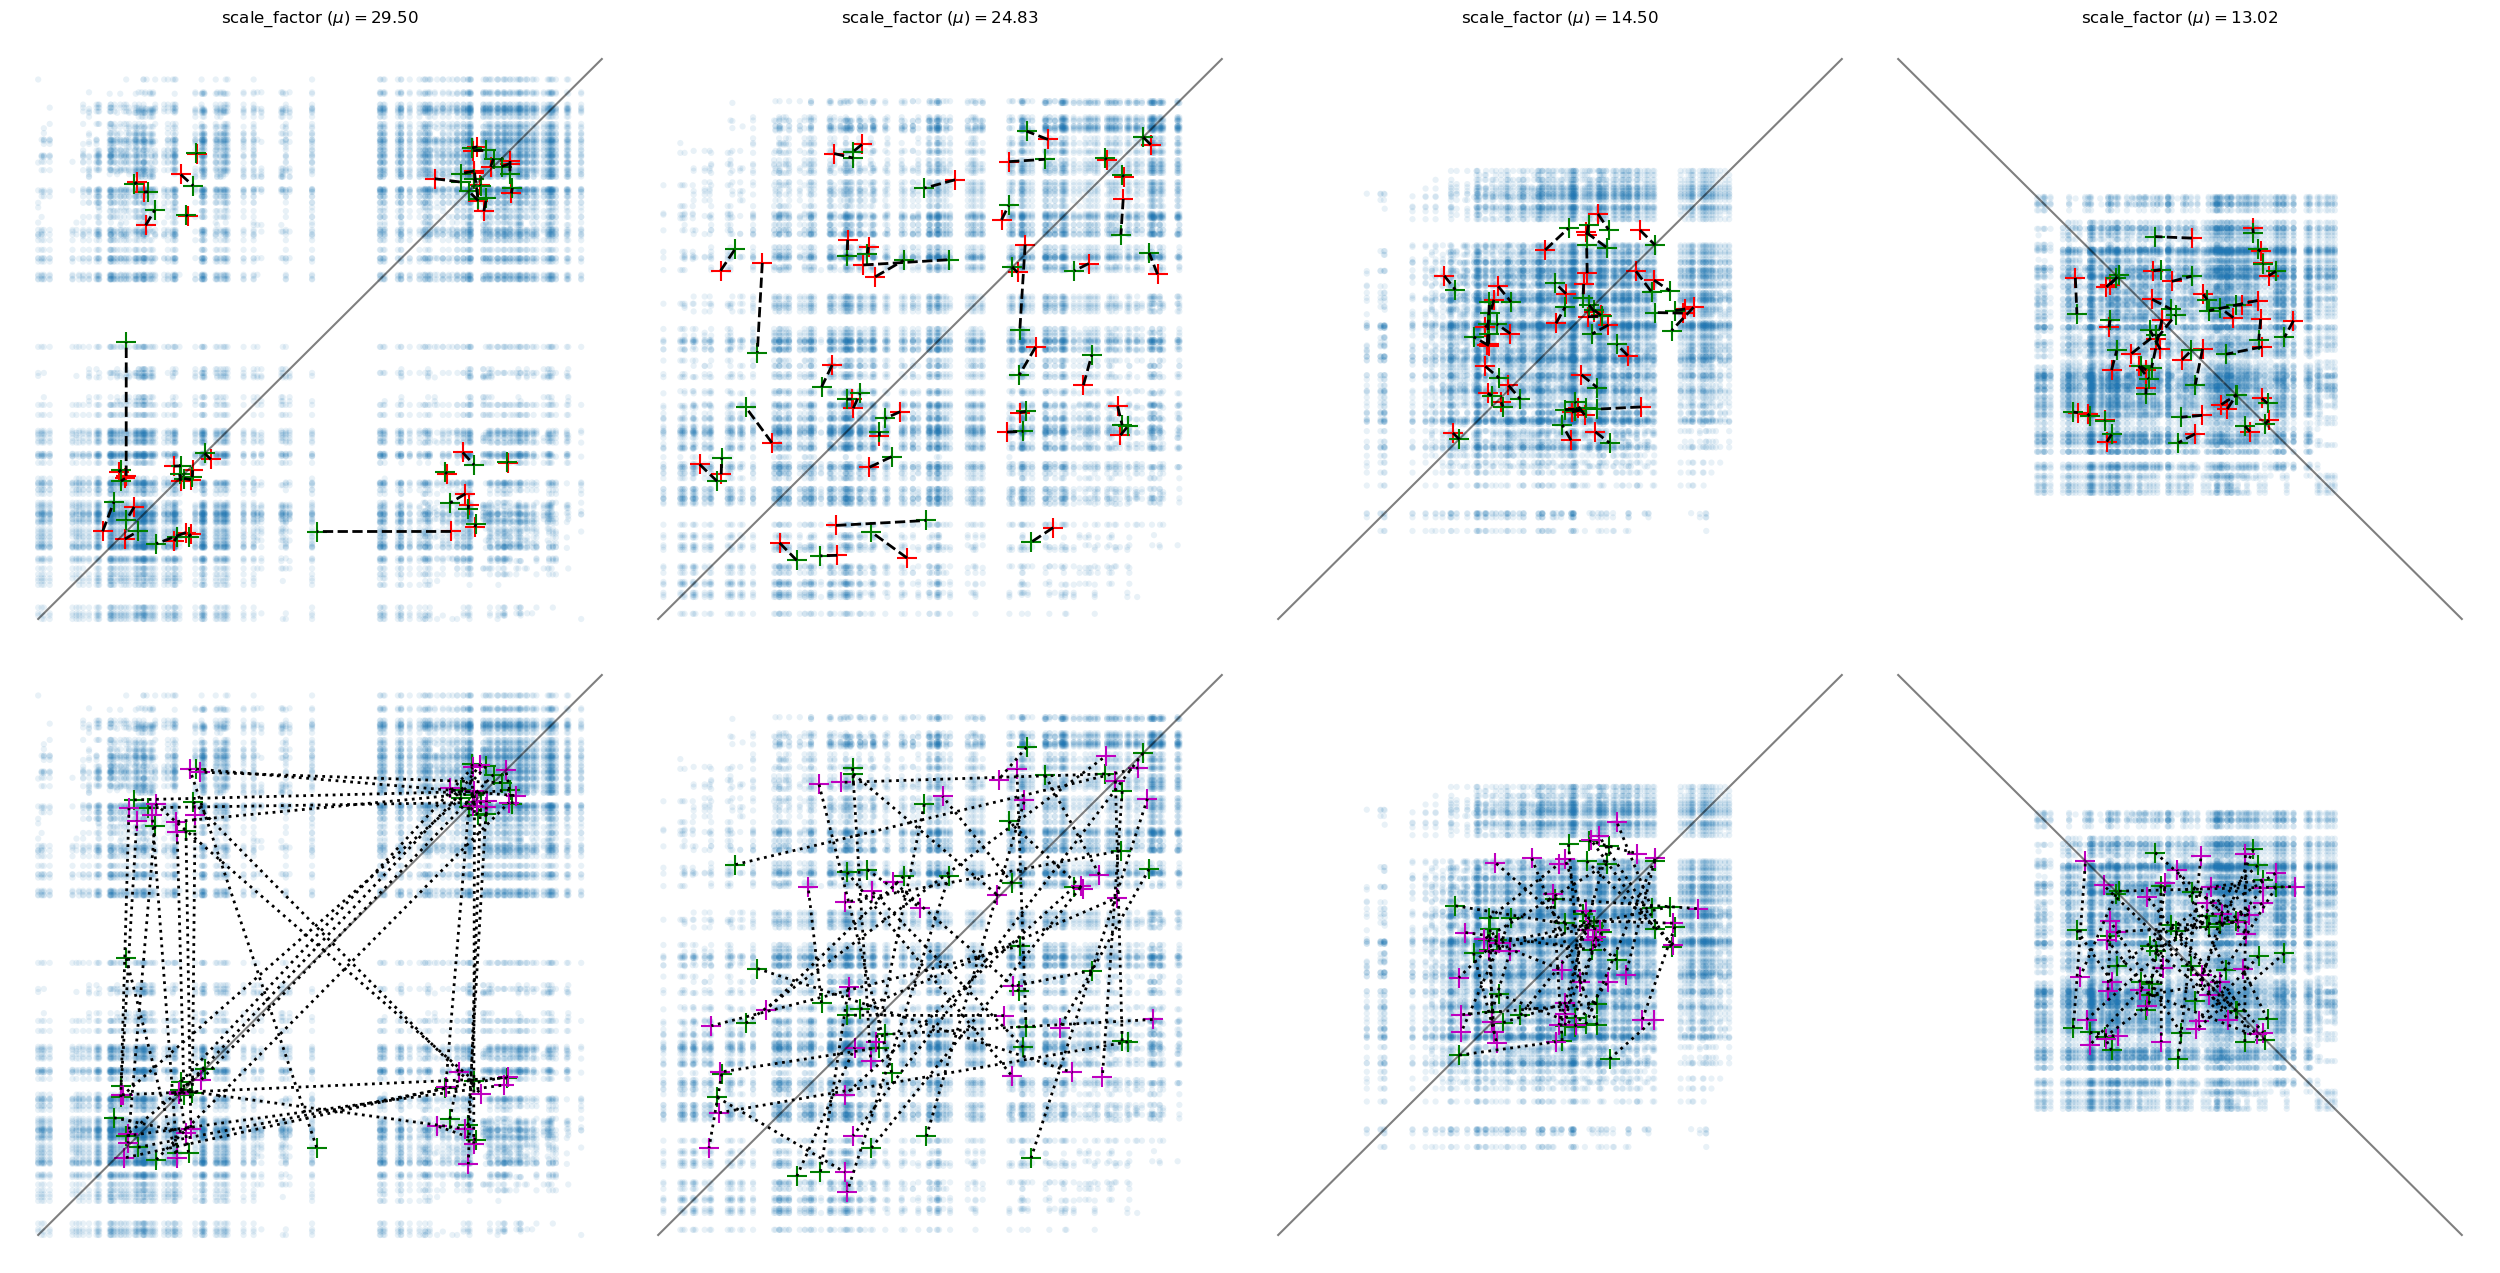

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(32, 16), gridspec_kw={'hspace': 0, 'wspace': 0})

maxval = np.max(np.abs(e_assign[:, 0]))
for i, ax in enumerate(axes.T):
    ax[0].axis("off")
    ax[1].axis("off")
    
    ax[0].set_title(f"scale_factor $(\\mu)={scale_factor[i]:.2f}$")
    for a in ax:
        a.scatter(e_assign[:, i], e_assign[:, i+n_vec_max], s=20, alpha=0.1, edgecolor="none")
        a.plot([-maxval, maxval], np.array([-maxval, maxval])*angle_signs[i], 'k', alpha=0.5)
    
    # ax[0].scatter(init_centers[:, i], init_centers[:, i+n_vec_max], s=200, c="g", marker="+")
    
    ax[0].scatter(initial_centers[:, i], initial_centers[:, i+n_vec_max], s=200, c="r", marker="+")
    ax[0].scatter(updated_centroids[:, i], updated_centroids[:, i+n_vec_max], s=200, c="g", marker="+")
    
    ax[1].scatter(updated_centroids[:, i], updated_centroids[:, i+n_vec_max], s=200, c="g", marker="+")
    ax[1].scatter(final_centroids[:, i], final_centroids[:, i+n_vec_max], s=200, c="m", marker="+")

    for k in range(n_kmeans):
        # ax[0].plot([init_centers[k, i], initial_centers[k, i]], 
        #            [init_centers[k, i+n_vec_max], initial_centers[k, i+n_vec_max]], color="k", ls=':', lw=1)
        
        ax[0].plot([initial_centers[k, i], updated_centroids[k, i]], 
                   [initial_centers[k, i+n_vec_max], updated_centroids[k, i+n_vec_max]], color="k", ls='--', lw=2)
        
        ax[1].plot([updated_centroids[k, i], final_centroids[k, i]],
                   [updated_centroids[k, i+n_vec_max], final_centroids[k, i+n_vec_max]], color="k", ls=':', lw=2)
        
        # ax.plot([kmeans.cluster_centers_[k, i], updated_centroids[k, i]], 
        #         [kmeans.cluster_centers_[k, i+n_vec_max], updated_centroids[k, i+n_vec_max]], color="k", ls='--', lw=2)

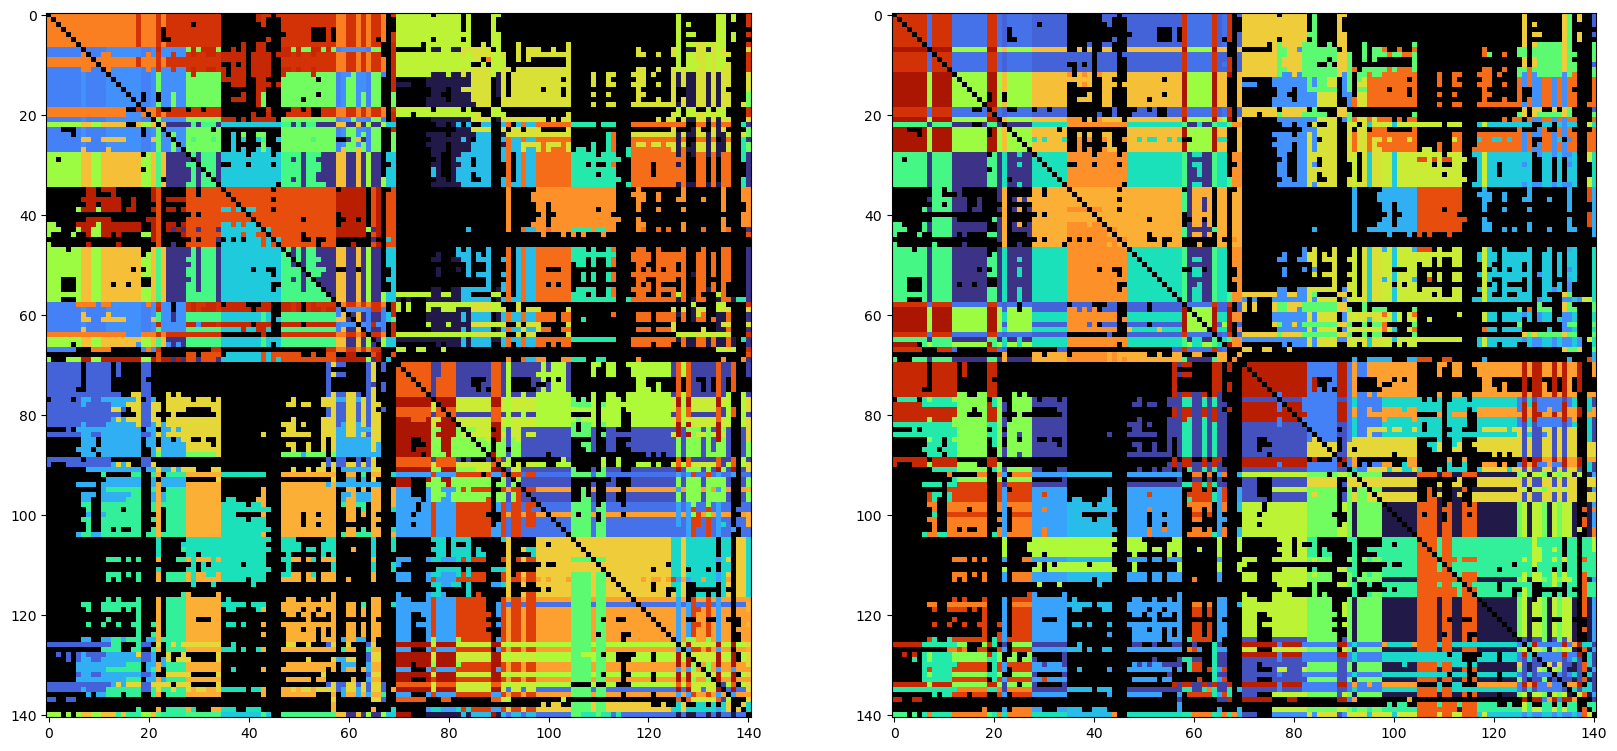

In [9]:
lab_mat = np.zeros((n_nodes, n_nodes), dtype=int)
lab_mat[graph != 0] = kmeans.labels_ + 1

fig, axes = plt.subplots(ncols=2, figsize=(20, 10))

axes[0].imshow(lab_mat, cmap=cluster_cmap, vmin=0, vmax=n_kmeans+1, interpolation="none")

axes[1].imshow(edge_clusters_mat, cmap=cluster_cmap, vmin=0, vmax=n_kmeans+1, interpolation="none")

In [27]:
from sklearn.cluster import AgglomerativeClustering

def consensus_matrix(all_labels, reorder=False, consensus_labels=False, consensus_k=None, fast=False):
    n_runs, n_samples = all_labels.shape

    consensus = np.zeros((n_samples, n_samples))

    for run in range(n_runs):
        labels = all_labels[run]
        same_cluster = (labels[:, None] == labels[None, :]).astype(int)
        consensus += same_cluster

    consensus /= n_runs

    if consensus_labels:
        dist = 1 - consensus

        if consensus_k is None:
            consensus_k = all_labels.max() + 1
        
        if fast:
            labels = AgglomerativeClustering(n_clusters=consensus_k,
                                             metric="precomputed",
                                             linkage="average").fit_predict(dist)
        else:
            cons_linkage = linkage(squareform(dist), method="average")
            labels = fcluster(cons_linkage, consensus_k, criterion="maxclust")
    
    if reorder:
        reorder_id = np.argsort(labels)
        consensus = consensus[reorder_id][:, reorder_id]

    return consensus, labels

## Consensus Clustering

In [ ]:
def consensus_score(consensus_matrix, consensus_label):
    sorter_lab = np.sort(consensus_label)
    within_mask = (sorter_lab[:, None] == sorter_lab[None, :])
    between_mask = ~within_mask

    within_vals = consensus_matrix[within_mask]
    between_vals = consensus_matrix[between_mask]
    
    # Not deflating the between values by the many zeros
    between_vals = between_vals[between_vals > 0]
    within_vals = within_vals[within_vals > 0]

    # return np.mean(within_vals, where=within_mask > 0), np.mean(between_vals, where=between_mask > 0)
    return np.mean(within_vals), np.mean(between_vals)

In [56]:
importlib.reload(dgsp)

# n_kmeans = 40
n_trials = 50

# all_n_kmeans = np.arange(10, 250, 5)
all_n_kmeans = np.arange(10, 100, 1)

all_labels = np.zeros((len(all_n_kmeans), n_trials, np.sum(graph != 0)), dtype=int)
all_labels_fix = np.zeros((len(all_n_kmeans), n_trials, np.sum(graph != 0)), dtype=int)

all_cons = np.zeros((len(all_n_kmeans), np.sum(graph != 0), np.sum(graph != 0)))
all_cons_fix = np.zeros((len(all_n_kmeans), np.sum(graph != 0), np.sum(graph != 0)))

cons_lab = np.zeros((len(all_n_kmeans), np.sum(graph != 0)), dtype=int)
cons_lab_fix = np.zeros((len(all_n_kmeans), np.sum(graph != 0)), dtype=int)

all_c_within = np.zeros(len(all_n_kmeans))
all_c_between = np.zeros(len(all_n_kmeans))

all_c_within_fix = np.zeros(len(all_n_kmeans))
all_c_between_fix = np.zeros(len(all_n_kmeans))

parallel = Parallel(n_jobs=np.min([14, n_trials]), return_as="generator_unordered")
counter = tqdm(total=len(all_n_kmeans)*n_trials)

# for k_i, n_kmeans in tqdm(enumerate(all_n_kmeans), total=len(all_n_kmeans)):
for k_i, n_kmeans in enumerate(all_n_kmeans):
    gen = parallel(delayed(dgsp.edge_bicommunities)(
        graph, U, V, 
        n_vec_max,
        method="kmeans",
        n_kmeans=n_kmeans,
        verbose=False,
        max_k=50,
        scale_S=scale_factor,
        clust_only=True,
        undirected=True,
        kwargs_kmeans1={"n_init":50, "init":"random"},
        kwargs_kmeans2={"n_init":1, "tol":1e-10}
        ) for t in range(n_trials))
    
    for t, labs in enumerate(gen):
        all_labels[k_i, t] = labs[0]
        all_labels_fix[k_i, t] = labs[1]
        counter.update(1)

    # print(f"n_kmeans: {n_kmeans}")
    # for t in range(n_trials):
    #     kmeans, e_assign = dgsp.edge_bicommunities(
    #         graph, U, V, 
    #         n_vec_max,
    #         method="kmeans",
    #         n_kmeans=n_kmeans,
    #         verbose=False,
    #         max_k=50,
    #         scale_S=scale_factor,
    #         # tol=1e-3,
    #         n_init=10,
    #         # max_iter=5,
    #         return_kmeans=True,
    #         # init=init_centers,
    #         # assign_only=True,
    #         undirected=False)

    #     all_labels[k_i, t] = kmeans.labels_
    #     initial_centers = kmeans.cluster_centers_.copy()

    #     angle_signs = np.array(
    #         [v.T @ u for u, v in zip(U[:, :n_vec_max].T,
    #                                 V[:, :n_vec_max].T)])
    #     flipped_centers = np.concatenate(
    #         [kmeans.cluster_centers_[:, n_vec_max:],
    #         kmeans.cluster_centers_[:, :n_vec_max]] * angle_signs, axis=1)

    #     dist_mat = cdist(kmeans.cluster_centers_, flipped_centers)
    #     row, col = linear_sum_assignment(dist_mat)
    #     updated_centroids = (kmeans.cluster_centers_[row] + flipped_centers[col])/2

    #     kmeans_2nd, e_assign = dgsp.edge_bicommunities(
    #         graph, U, V, 
    #         n_vec_max,
    #         method="kmeans",
    #         n_kmeans=n_kmeans,
    #         verbose=False,
    #         max_k=50,
    #         scale_S=scale_factor,
    #         tol=1e-10,
    #         n_init=1,
    #         init=updated_centroids,
    #         return_kmeans=True,
    #         # assign_only=True,
    #         undirected=False,)
    #     all_labels_fix[k_i, t] = kmeans_2nd.labels_

    # all_cons[k_i], cons_lab[k_i] = consensus_matrix(all_labels[k_i], reorder=True, consensus_labels=True)
    # all_cons_fix[k_i], cons_lab_fix[k_i] = consensus_matrix(all_labels_fix[k_i], reorder=True, consensus_labels=True)

    cons, cons_lab[k_i] = consensus_matrix(all_labels[k_i], reorder=True, consensus_labels=True)
    cons_fix, cons_lab_fix[k_i] = consensus_matrix(all_labels_fix[k_i], reorder=True, consensus_labels=True)

    all_c_within[k_i], all_c_between[k_i] = consensus_score(cons, cons_lab[k_i])
    all_c_within_fix[k_i], all_c_between_fix[k_i] = consensus_score(cons_fix, cons_lab_fix[k_i])
    
    # all_cons[k_i], cons_lab[k_i] = consensus_matrix(all_labels[k_i], consensus_labels=True)# , reorder=True)
    # all_cons_fix[k_i], cons_lab_fix[k_i] = consensus_matrix(all_labels_fix[k_i], consensus_labels=True)# , reorder=True)
counter.close()

  0%|          | 0/4500 [00:00<?, ?it/s]

/Users/acionca/fsl/envs/dgsp/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/acionca/fsl/envs/dgsp/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


- Just a note that it takes 1min29 for 80 (10*8) iter in parallel (njobs=12)
- While it takes 1min36 for the same 80 (10*8) iter in series (njobs=1)
- Then it took 9min43 for 500 (10*50) iter in parallel (njobs=10, 20 init)
- Faster Implem took 9min34 for 500 (10*50) iter in parallel (njobs=10, 20 init)
- Faster Implem took XXminXX for 1800 (20*90) iter in parallel (njobs=10, 20 random init)

In [47]:
# fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

# cons_mixed = all_cons.sum(axis=0)/len(all_cons)
# axes[0].imshow(all_cons[20], cmap="viridis", vmin=0, vmax=1, interpolation="none")

# axes[1].imshow(cons_mixed, cmap="viridis", vmin=0, vmax=1, interpolation="none")

In [48]:
# from sklearn.metrics import silhouette_score

# dist = 1 - cons_mixed
# cons_linkage = linkage(squareform(dist), method="average")

# silh = np.zeros(len(all_n_kmeans))
# labs = np.zeros((len(all_n_kmeans), len(cons_lab[0])), dtype=int)
# for k_i, k in enumerate(all_n_kmeans):
#     labs[k_i] = fcluster(cons_linkage, k, criterion="maxclust")
#     silh[k_i] = silhouette_score(dist, labels=labs[k_i], metric="precomputed")

In [21]:
# fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

# sel_id = 1

# axes[0].plot(all_n_kmeans, silh)
# axes[0].axvline(all_n_kmeans[sel_id], color="red")

# sort_id = np.argsort(labs[sel_id])
# axes[1].imshow(cons_mixed[sort_id][:, sort_id], cmap="viridis", vmin=0, vmax=1, interpolation="none")

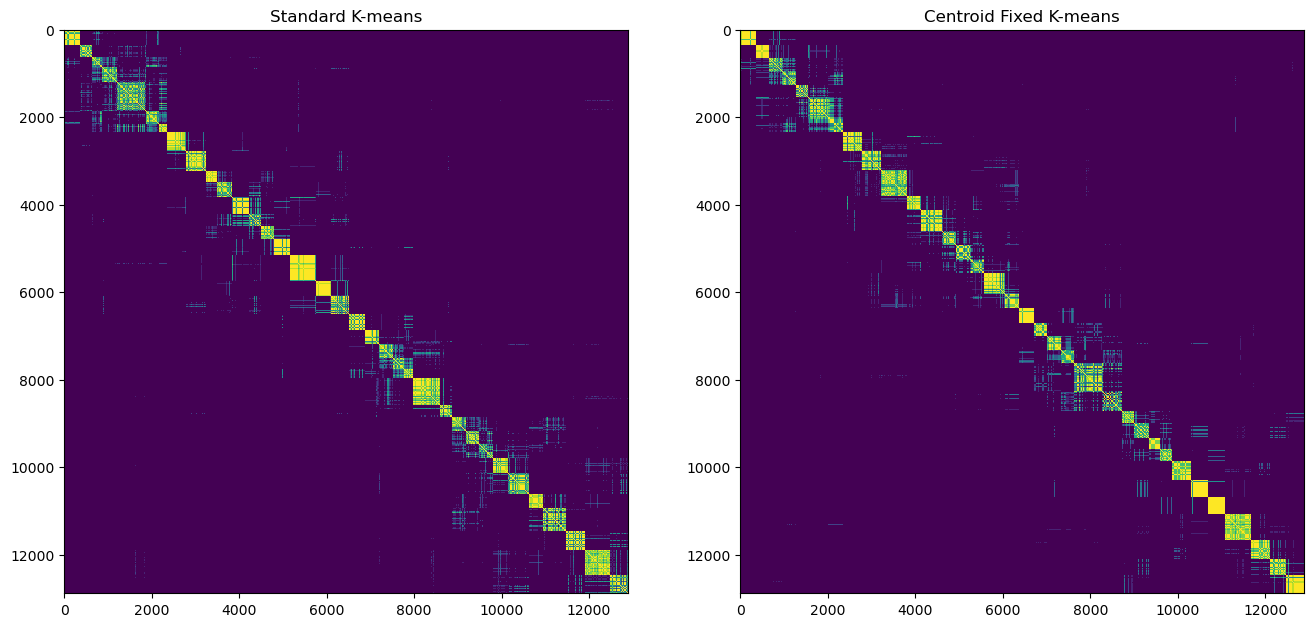

In [ ]:
# consensus, c_lab = consensus_matrix(all_labels[5], reorder=True, consensus_labels=True)
# consensus_fix, c_lab_fix = consensus_matrix(all_labels_fix[5], reorder=True, consensus_labels=True)

# fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

# axes[0].set_title("Standard K-means")
# axes[0].imshow(consensus, cmap="viridis",
#                vmin=0, vmax=1,
#                interpolation="none")

# axes[1].set_title("Centroid Fixed K-means")
# axes[1].imshow(consensus_fix, cmap="viridis",
#                vmin=0, vmax=1,
#                interpolation="none")

In [54]:
# fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

# axes[0].imshow(all_cons[5])

# within_mask = (cons_lab[5][:, None] == cons_lab[5][None, :])
# axes[1].imshow(within_mask)

# sorter_lab = np.sort(cons_lab[5])
# within_mask = (sorter_lab[:, None] == sorter_lab[None, :])
# axes[2].imshow(within_mask)

In [ ]:
# all_c_within = np.zeros(len(all_n_kmeans))
# all_c_between = np.zeros(len(all_n_kmeans))

# all_c_within_fix = np.zeros(len(all_n_kmeans))
# all_c_between_fix = np.zeros(len(all_n_kmeans))

# for k_i in range(len(all_n_kmeans)):
#     all_c_within[k_i], all_c_between[k_i] = consensus_score(all_cons[k_i], cons_lab[k_i])
#     all_c_within_fix[k_i], all_c_between_fix[k_i] = consensus_score(all_cons_fix[k_i], cons_lab_fix[k_i])

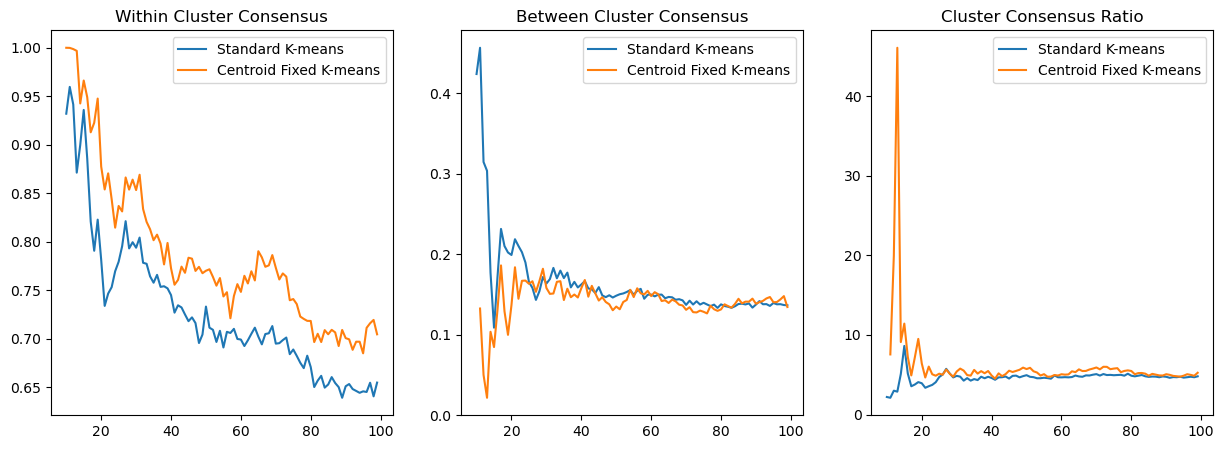

In [57]:
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))

axes[0].plot(all_n_kmeans, all_c_within, label="Standard K-means")
axes[0].plot(all_n_kmeans, all_c_within_fix, label="Centroid Fixed K-means")
axes[0].set_title("Within Cluster Consensus")
axes[0].legend()

axes[1].plot(all_n_kmeans, all_c_between, label="Standard K-means")
axes[1].plot(all_n_kmeans, all_c_between_fix, label="Centroid Fixed K-means")
axes[1].set_title("Between Cluster Consensus")
axes[1].legend()

c_ratio = all_c_within / all_c_between
c_ratio_fix = all_c_within_fix / all_c_between_fix

axes[2].plot(all_n_kmeans, c_ratio, label="Standard K-means")
axes[2].plot(all_n_kmeans, c_ratio_fix, label="Centroid Fixed K-means")
axes[2].set_title("Cluster Consensus Ratio")
axes[2].legend()

[10 13 12 11 19 14 18 15 20 22]
[10 13 12 15 19 14 11 16 18 20]


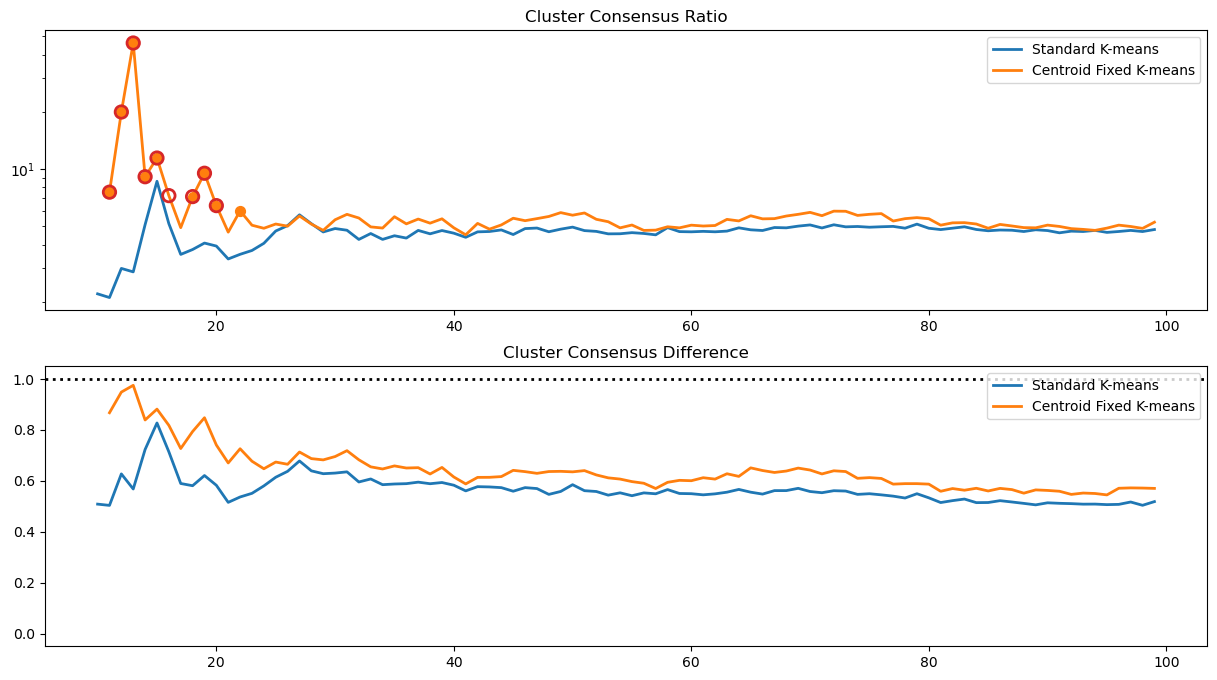

In [58]:
fig, axes = plt.subplots(nrows=2, figsize=(15, 8))

n_best = 10
best_ratio = np.flip(np.argsort(c_ratio_fix))
best_r_diff = np.flip(np.argsort(c_ratio_fix - c_ratio))

axes[0].plot(all_n_kmeans, c_ratio, label="Standard K-means", lw=2, zorder=1)
axes[0].plot(all_n_kmeans, c_ratio_fix, label="Centroid Fixed K-means", lw=2, zorder=1)
axes[0].set_title("Cluster Consensus Ratio")
axes[0].legend()
axes[0].set_yscale("log")

print(all_n_kmeans[best_r_diff[:n_best]])
for i in best_r_diff[:n_best]:
    axes[0].scatter(all_n_kmeans[i], c_ratio_fix[i], s=50, c='tab:orange', marker='o')

print(all_n_kmeans[best_ratio[:n_best]])
for i in best_ratio[:n_best]:
    axes[0].scatter(all_n_kmeans[i], c_ratio_fix[i], s=80, c='none', marker='o', edgecolor="tab:red", lw=2)

axes[1].axhline(1, color="k", lw=2, ls=':')
axes[1].axhline(0, color="w", lw=1)
axes[1].plot(all_n_kmeans, all_c_within-all_c_between, label="Standard K-means", lw=2)
axes[1].plot(all_n_kmeans, all_c_within_fix-all_c_between_fix, label="Centroid Fixed K-means", lw=2)
axes[1].set_title("Cluster Consensus Difference")
axes[1].legend()

<Axes: ylabel='Consensus Ratio'>

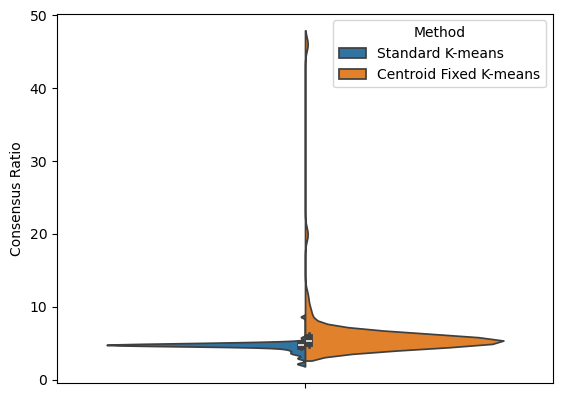

In [59]:
from seaborn import violinplot

merged_df = pd.DataFrame({
    "Consensus Ratio": np.concatenate([all_c_within/all_c_between, all_c_within_fix/all_c_between_fix]),
    "Method": ["Standard K-means"]*len(all_n_kmeans) + ["Centroid Fixed K-means"]*len(all_n_kmeans)
})

violinplot(data=merged_df, y="Consensus Ratio", hue="Method", split=True, bw_adjust=0.5)

In [ ]:
fig, axes = plt.subplots(figsize=(16, 6), sharey=True, sharex=True)

all_means = np.zeros(len(all_n_kmeans))
all_means_fix = np.zeros(len(all_n_kmeans))

all_k_rat = []
all_k_rat_fix = []
for k_i in range(len(all_n_kmeans)):

    k_ratio = np.zeros(all_n_kmeans[k_i])
    k_ratio_fix = np.zeros(all_n_kmeans[k_i])

    x_scatter = all_n_kmeans[k_i] + np.random.uniform(-0.2, 0.2, all_n_kmeans[k_i])

    sort_lab = np.sort(cons_lab[k_i])
    sort_lab_fix = np.sort(cons_lab_fix[k_i])

    for k in range(all_n_kmeans[k_i]):
        k_mask = (sort_lab == k + 1)
        if sum(k_mask) < 1:
            val_within = np.array([1e-8])
            val_between = np.array([1e-8])
        else:
            val_within = all_cons[k_i][k_mask][:, k_mask]
            val_between = all_cons[k_i][k_mask][:, ~k_mask]

        # k_ratio[k] = val_within[val_within > 0].mean() / (val_between[val_between > 0].mean())
        k_ratio[k] = val_within.mean() - val_between.mean()
        
        k_mask = (sort_lab_fix == k + 1)
        if sum(k_mask) < 1:
            val_within = np.array([1e-8])
            val_between = np.array([1e-8])
        else:
            val_within = all_cons_fix[k_i][k_mask][:, k_mask] # + 1e-5
            val_between = all_cons_fix[k_i][k_mask][:, ~k_mask] # + 1e-5

        # k_ratio_fix[k] = val_within[val_within > 0].mean() / (val_between[val_between > 0].mean())
        k_ratio_fix[k] = val_within.mean() - val_between.mean()
    
    all_k_rat.append(k_ratio)
    all_k_rat_fix.append(k_ratio_fix)

    axes.scatter(x_scatter-0.2, k_ratio, alpha=0.3, s=20, edgecolor="none", color="tab:blue")
    axes.scatter(x_scatter+0.2, k_ratio_fix, alpha=0.3, s=20, edgecolor="none", color="tab:red")
    # axes[0].scatter(x_scatter, k_ratio, alpha=0.3, s=20, edgecolor="none")
    # axes[1].scatter(x_scatter, k_ratio_fix, alpha=0.3, s=20, edgecolor="none")

    all_means[k_i] = k_ratio.mean()
    all_means_fix[k_i] = k_ratio_fix.mean()

axes.plot(all_n_kmeans, all_means, lw=2, color="tab:blue")
axes.plot(all_n_kmeans, all_means_fix, lw=2, color="tab:red")

## Conjugates

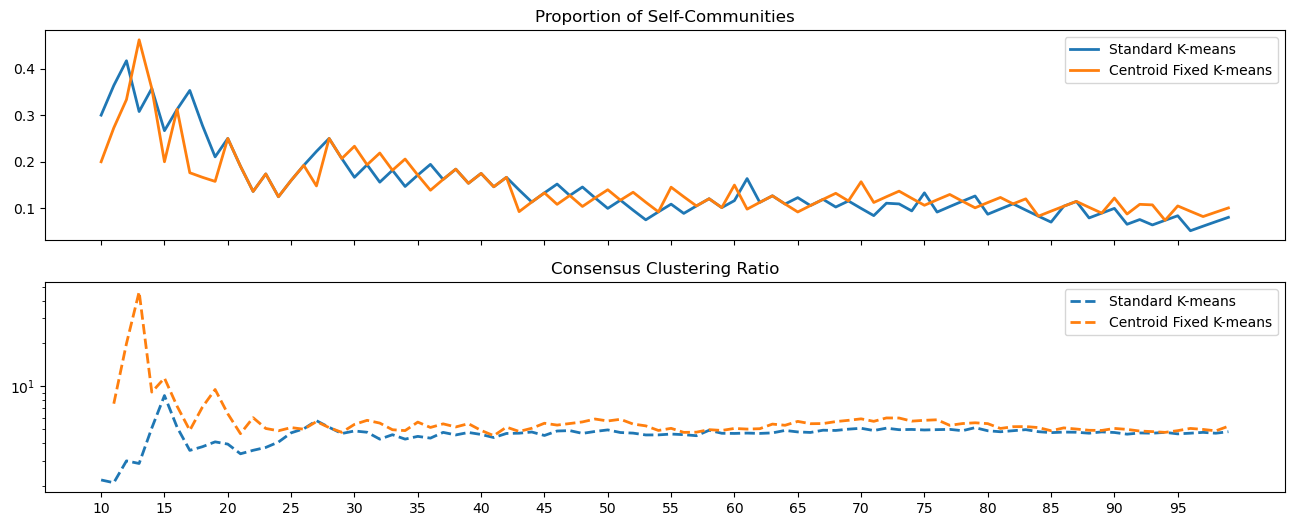

In [61]:
all_e_matrices = np.zeros((len(all_n_kmeans), n_nodes, n_nodes)).astype(int)
all_e_matrices_fix = np.zeros((len(all_n_kmeans), n_nodes, n_nodes)).astype(int)

all_send = []
all_receive = []

n_bicom_type = np.zeros((2, len(all_n_kmeans)))
n_bicom_type_fix = np.zeros((2, len(all_n_kmeans)))

for k_i, k in enumerate(all_n_kmeans):
    all_e_matrices[k_i][graph != 0] = cons_lab[k_i]
    all_e_matrices_fix[k_i][graph != 0] = cons_lab_fix[k_i]
    
    s, r = dgsp.get_node_clusters(cons_lab[k_i], all_e_matrices[k_i])
    sr_vec = np.concatenate([s, r], axis=1)
    conj = np.concatenate([r, s], axis=1)
    corr, row, col = dgsp.reorder_corr(dgsp.columnwise_corr(sr_vec.T, conj.T))
    n_self = np.array([r == c for r, c in zip(row, col)]).sum()
    n_bicom_type[0, k_i] = n_self
    n_bicom_type[1, k_i] = k - n_self
    
    s, r = dgsp.get_node_clusters(cons_lab_fix[k_i], all_e_matrices_fix[k_i])
    sr_vec = np.concatenate([s, r], axis=1)
    conj = np.concatenate([r, s], axis=1)
    corr, row, col = dgsp.reorder_corr(dgsp.columnwise_corr(sr_vec.T, conj.T))
    n_self = np.array([r == c for r, c in zip(row, col)]).sum()
    n_bicom_type_fix[0, k_i] = n_self
    n_bicom_type_fix[1, k_i] = k - n_self

fig, axes = plt.subplots(nrows=2, figsize=(16, 6), sharex=True)
axes[0].plot(all_n_kmeans, n_bicom_type[0] / all_n_kmeans, label="Standard K-means", lw=2)
axes[0].plot(all_n_kmeans, n_bicom_type_fix[0] / all_n_kmeans, label="Centroid Fixed K-means", lw=2)

axes[0].set_xticks(all_n_kmeans[::5])
axes[0].set_title("Proportion of Self-Communities")
axes[0].legend()

axes[1].plot(all_n_kmeans, all_c_within/all_c_between, ls="--", label="Standard K-means", lw=2, color="tab:blue")
axes[1].plot(all_n_kmeans, all_c_within_fix/all_c_between_fix, ls="--", label="Centroid Fixed K-means", lw=2, color="tab:orange")
axes[1].set_yscale("log")

axes[1].set_xticks(all_n_kmeans[::5])
axes[1].set_title("Consensus Clustering Ratio")
axes[1].legend()